# Visualización de datos

In [ ]:
# Librerias
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import folium
from folium import plugins
import numpy as np

In [2]:
# Leer archivo
filepath="../data/events.parquet"
df = pd.read_parquet(filepath)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   GLOBALEVENTID          10000 non-null  Int64  
 1   SQLDATE                10000 non-null  str    
 2   Actor1Name             10000 non-null  str    
 3   Actor2Name             10000 non-null  str    
 4   EventCode              10000 non-null  str    
 5   GoldsteinScale         10000 non-null  float64
 6   AvgTone                10000 non-null  float64
 7   NumMentions            10000 non-null  Int64  
 8   ActionGeo_CountryCode  10000 non-null  str    
 9   ActionGeo_Lat          9997 non-null   float64
 10  ActionGeo_Long         9997 non-null   float64
 11  EVENTDESCRIPTION       308 non-null    str    
 12  CountryName            9996 non-null   str    
dtypes: Int64(2), float64(4), str(7)
memory usage: 1.4 MB


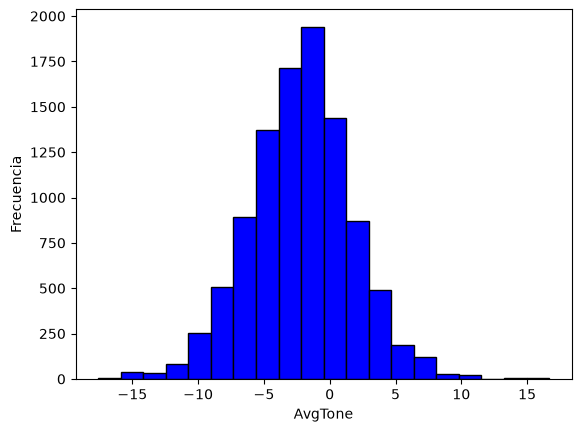

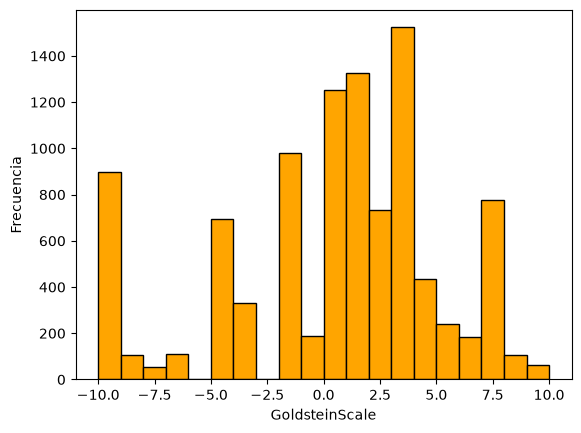

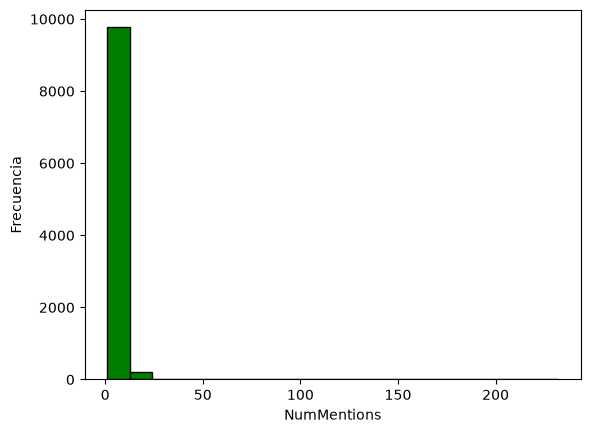

In [5]:
# Generar histograma de la columna "AvgTone"
import matplotlib.pyplot as plt
bins = 20  # Número de bins para el histograma
plt.hist(df["AvgTone"].dropna(), edgecolor='black',bins=bins,color='blue')
plt.xlabel("AvgTone")
plt.ylabel("Frecuencia")
plt.show()

# Histograma de la columna GoldsteinScale
plt.hist(df["GoldsteinScale"].dropna(), edgecolor='black',bins=bins,color='orange')
plt.xlabel("GoldsteinScale")
plt.ylabel("Frecuencia")
plt.show()

# Histograma de la columna NumMentions
plt.hist(df["NumMentions"].dropna(), edgecolor='black',bins=bins,color='green')
plt.xlabel("NumMentions")
plt.ylabel("Frecuencia")
plt.show()

In [16]:
df["NumMentions"].describe()


count     10000.0
mean       5.6968
std      4.831977
min           1.0
25%           2.0
50%           4.0
75%          10.0
max         232.0
Name: NumMentions, dtype: Float64

15.0


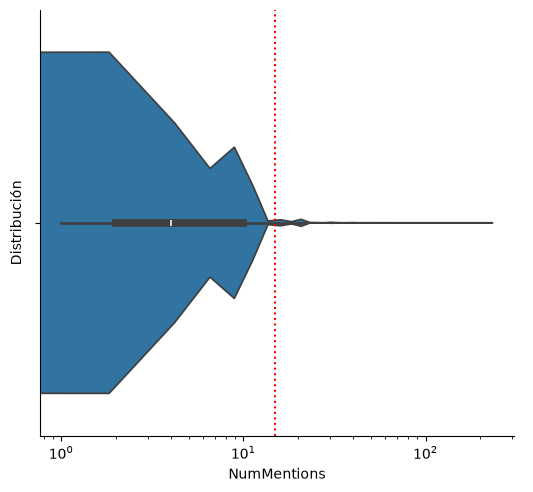

In [20]:
# Encontrar 95 % de los datos 
percentil=np.percentile(df["NumMentions"],98)
print(percentil)
sns.catplot(data=df, x="NumMentions", kind="violin")
plt.xscale("log") # Escala logaritmica para la visualización
plt.xlabel("NumMentions")
plt.ylabel("Distribución")
plt.axvline(x=percentil, color='red', linestyle=':', linewidth=1.5)
plt.show()

In [24]:
# Países con mayor numero de eventos
df.groupby("CountryName").size().sort_values(ascending=False).head(10)

CountryName
United States     2877
Israel             606
Nigeria            482
Australia          326
Iran               311
India              283
Russia             276
United Kingdom     254
Colombia           242
Mexico             228
dtype: int64

In [27]:
df.groupby("CountryName")["AvgTone"].mean().sort_values(ascending=True).head(10)

CountryName
Madagascar     -9.490741
Yemen          -8.200190
Nicaragua      -7.175341
Honduras       -7.175341
Sierra Leone   -6.332854
Cambodia       -6.017337
Djibouti       -5.977679
Kosovo         -5.882353
West Bank      -5.626138
Zambia         -5.531804
Name: AvgTone, dtype: float64

In [63]:
top = (
    df.groupby("CountryName")["AvgTone"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)
top

CountryName
Andorra      5.343511
Bhutan       5.165826
Namibia      4.456999
Senegal      4.207389
Slovenia     3.846154
Tunisia      3.789761
Macedonia    3.703704
Armenia      3.696737
Tanzania     3.323263
Lithuania    3.261246
Name: AvgTone, dtype: float64

In [98]:
import geopandas as gpd

def plot_map(df,variable,num=10,ascending=True):
    world = gpd.read_file(
        "../Data/ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp"
    )
    top = (
        df.groupby("CountryName")[variable]
        .mean()
        .sort_values(ascending=ascending)
        .head(num)
    )
    word="mejor"
    cmap="hot"
    if ascending:
        word="menor"
        cmap="winter"
    print(f"Top paises con {word} {variable}")
    print(top)

    countries = top.index.tolist()

    selected = world[world["NAME"].isin(countries)]

    selected = world[world["NAME"].isin(top.index)].copy()

    selected[variable] = selected["NAME"].map(top)

    fig, ax = plt.subplots(figsize=(15, 8))

    world.plot(
        ax=ax,
        color="lightgray",
        edgecolor="black",
        linewidth=0.4
    )

    selected.plot(
        ax=ax,
        column=variable,
        cmap=cmap,
        legend=True,
        edgecolor="black",
        linewidth=1.2
    )

    ax.set_title(f"{num} países con {word} {variable} ")
    ax.set_axis_off()
    plt.savefig(f"images/{num}Paises_{word}_{variable}.jpg")

    plt.show()





Top paises con mejor AvgTone
CountryName
Andorra               5.343511
Bhutan                5.165826
Namibia               4.456999
Senegal               4.207389
Slovenia              3.846154
Tunisia               3.789761
Macedonia             3.703704
Armenia               3.696737
Tanzania              3.323263
Lithuania             3.261246
Liechtenstein         3.200104
Burkina Faso          2.901354
Dominican Republic    2.879581
Hong Kong             2.806320
Congo                 2.792681
Uruguay               2.464760
South Sudan           2.219626
Estonia               2.064897
Latvia                2.045455
Guam                  1.781737
Panama                1.644539
Luxembourg            1.510468
Malaysia              1.474767
Croatia               1.352862
Jersey                1.204504
Nepal                 1.190459
Costa Rica            1.049838
Burundi               0.971669
Austria               0.874675
India                 0.795802
Mauritius             0.78976

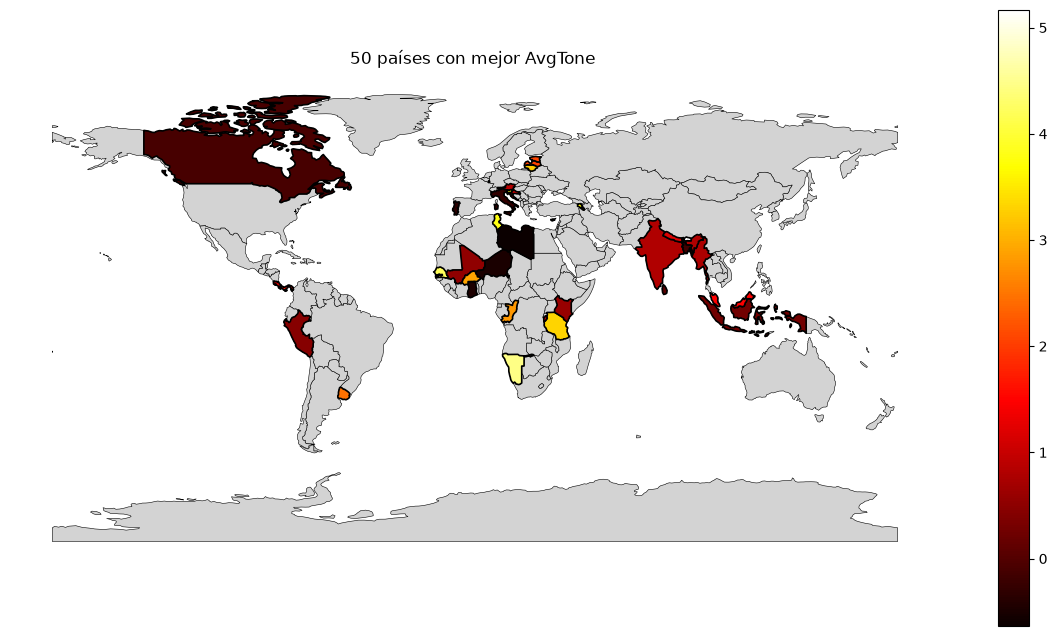

Top paises con mejor GoldsteinScale
CountryName
Gambia                              7.000000
Tunisia                             5.200000
Croatia                             4.733333
Chad                                4.700000
Oman                                4.422222
Myanmar                             4.300000
Denmark                             4.250000
Macedonia                           4.000000
Mali                                3.850000
Austria                             3.625000
Kosovo                              3.500000
Tanzania                            3.400000
Namibia                             3.200000
Democratic Republic of the Congo    3.114286
Bolivia                             3.075000
Sri Lanka                           3.056250
Reunion                             3.050000
Nicaragua                           3.000000
Dominican Republic                  3.000000
Bangladesh                          3.000000
South Sudan                         3.000000
Netherl

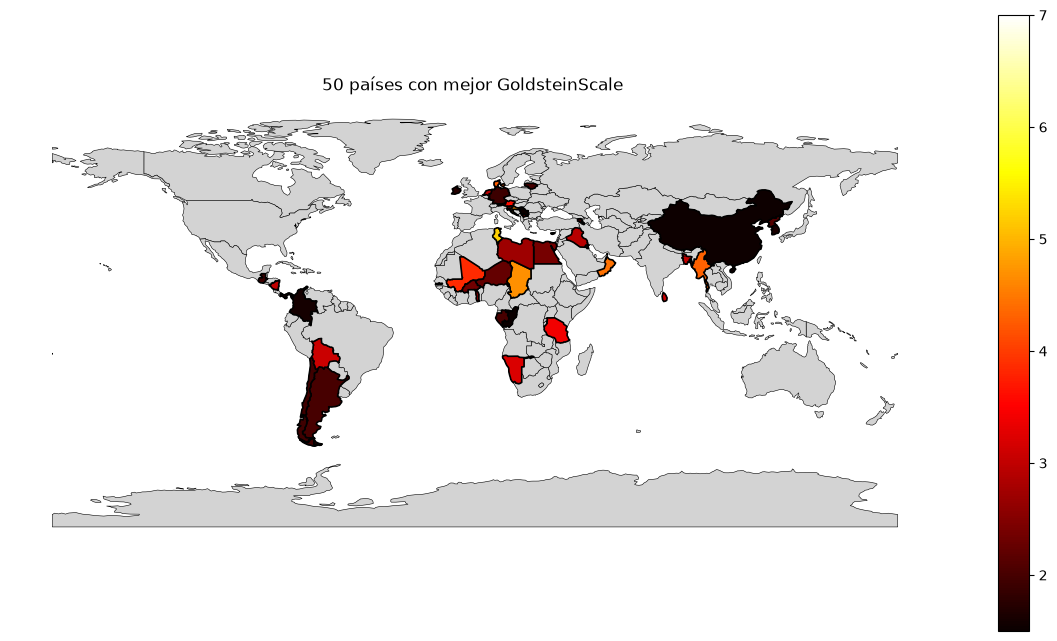

Top paises con menor AvgTone
CountryName
Madagascar                         -9.490741
Yemen                              -8.200190
Nicaragua                          -7.175341
Honduras                           -7.175341
Sierra Leone                       -6.332854
Cambodia                           -6.017337
Djibouti                           -5.977679
Kosovo                             -5.882353
West Bank                          -5.626138
Zambia                             -5.531804
Lebanon                            -5.329724
Bolivia                            -5.301876
Azerbaijan                         -5.154639
Gibraltar                          -5.120482
Serbia                             -5.071514
Guatemala                          -4.921273
Mauritania                         -4.645458
Belarus                            -4.539106
Israel                             -4.363465
Uganda                             -4.142260
Democratic Republic of the Congo   -4.121750
Qatar         

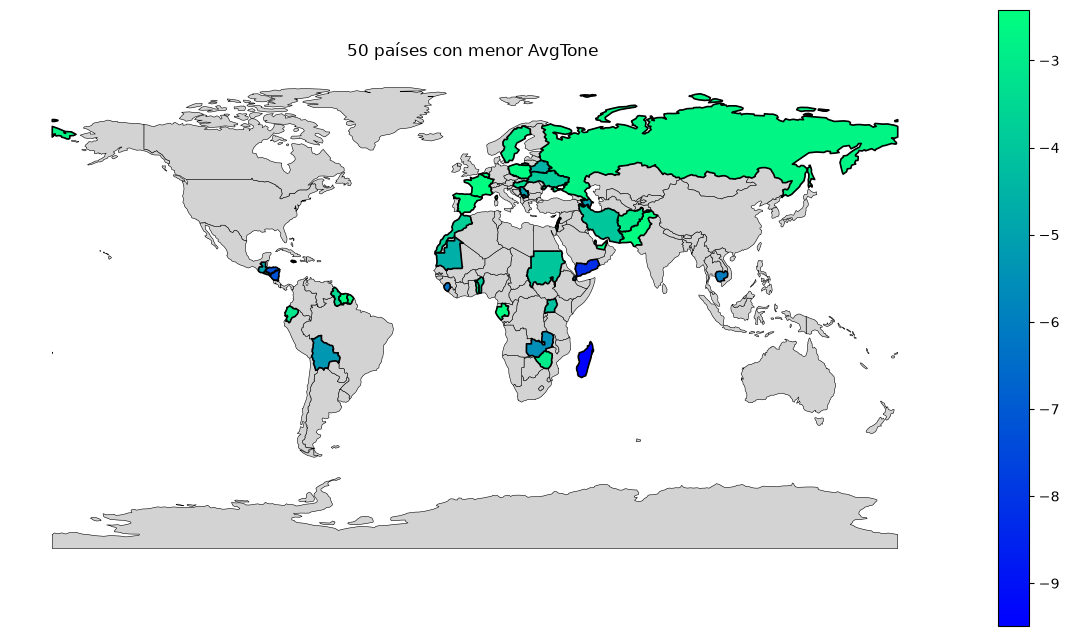

Top paises con menor GoldsteinScale
CountryName
Gibraltar                          -10.000000
Ethiopia                            -6.800000
Azerbaijan                          -5.000000
Honduras                            -5.000000
Sudan                               -4.916667
Jamaica                             -4.666667
Estonia                             -4.250000
Yemen                               -4.220000
Palau                               -4.000000
Faroe Islands                       -4.000000
Madagascar                          -4.000000
Thailand                            -3.500000
Burundi                             -3.300000
Djibouti                            -3.163636
Belarus                             -3.000000
Sierra Leone                        -2.833333
Costa Rica                          -2.754545
Lebanon                             -2.600000
Qatar                               -2.525000
Greenland                           -2.157143
West Bank                       

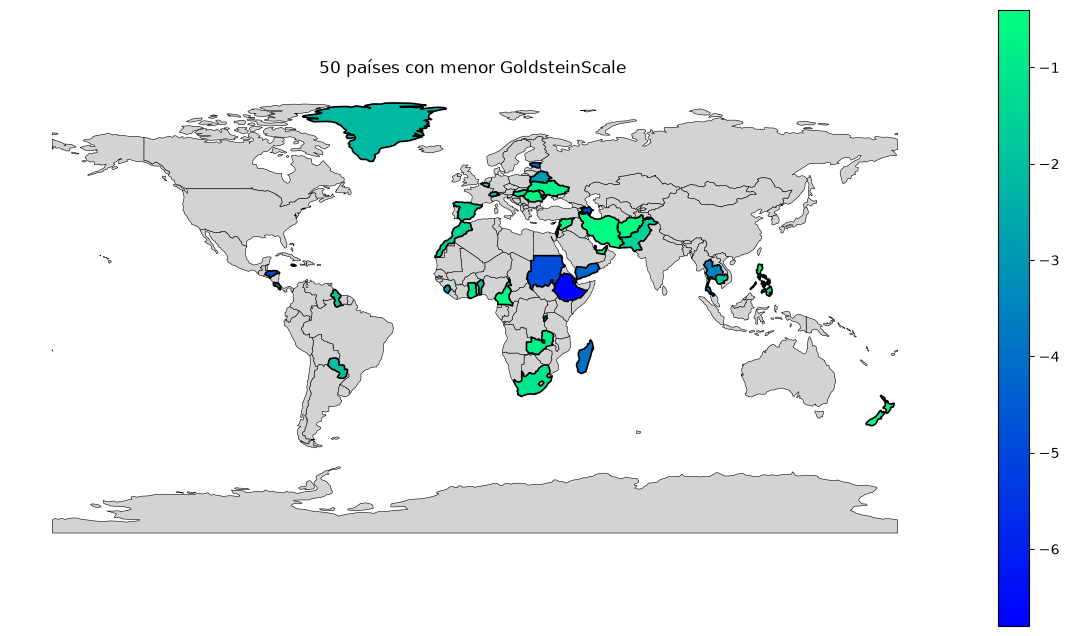

In [100]:
plot_map(df,"AvgTone",num=50,ascending=False)
plot_map(df,"GoldsteinScale",num=50,ascending=False)

plot_map(df,"AvgTone",num=50,ascending=True)
plot_map(df,"GoldsteinScale",num=50,ascending=True)

In [103]:

columnas=["NumMentions"]
for i in columnas: 
    heat_data = (
        df[["ActionGeo_Lat", "ActionGeo_Long", i]]
        .dropna()
        .values
        .tolist()
    )

    m = folium.Map(
        location=[20, 0],
        zoom_start=2
    )


    folium.TileLayer(
        "CartoDB positron",
        name="Claro"
    ).add_to(m)

    folium.TileLayer(
        "CartoDB dark_matter",
        name="Oscuro"
    ).add_to(m)

    folium.TileLayer(
        "Esri WorldImagery",
        name="Satélite"
    ).add_to(m)

    plugins.HeatMap(
        heat_data,
        radius=10,
        blur=5
    ).add_to(m)
    folium.LayerControl().add_to(m)
    m.save(f"images/heatmap_gdelt_{i}.html")

